In [17]:
import numpy as np
import torch 
import matplotlib.pyplot as plt

from GENERAL_FUNCTIONS.functions_torch import *
from ATMOSPHERE.atmosphere import *
from PYRAMID.Pyramid_WFS import *

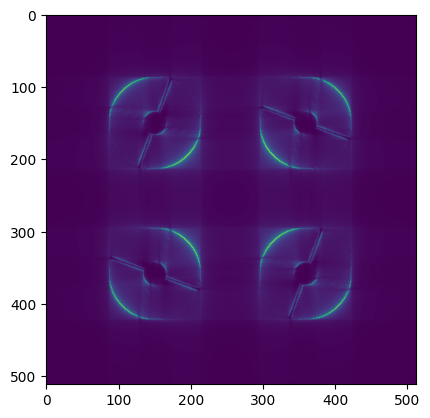

In [42]:
device = "cpu"
dtype = torch.float32
precision = get_precision("single")

telescope_diameter = 3.0 # meters
telescope_resolution = 128 # pixels
telescope_samp = 2
telescope_obstruction_diameter = 32 # pixels
telescope_spiders = 4 # scalar
telescope_spiders_pixels = 4 # pixels
telescope_spiders_degree = 20

telescope_pupil = circular_pupil_telescope(n = telescope_resolution, device=device, dtype=dtype, spiders=telescope_spiders,spiders_px=telescope_spiders_pixels,central_obstruction_diam_px=telescope_obstruction_diameter,spider_angle_deg=telescope_spiders_degree)

output_resolution = 128
wfs = Pyramid(telescope_resolution=telescope_resolution, telescope_diameter=telescope_diameter,
              telescope_samp=telescope_samp, output_resolution = output_resolution,
              nHeads=4, alpha= 2.8,device=device,precision=precision)

I = wfs.propagate(pupil= telescope_pupil,phi= telescope_pupil,return_both=True)[0].squeeze()

plt.imshow(I)